# Task i - Part 2

Connect the electricity sector with, at least another sector (e.g. heating or transport), and co-optimise all the sectors. Discuss your results.

In [63]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

## Technologies data and costs
The technology cost and performance assumptions are taken from the PyPSA Technology Data database (PyPSA/technology-data, v0.11.0).

In [64]:
year = 2030

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [65]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"] # Assign the natural gas fuel cost to the CCGT technology (fuel prices are stored under "gas" in the database)
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"] # cost of CCGT with CO2 emissions
costs.at["coal", "CO2 intensity"] = costs.at["coal", "CO2 intensity"] # cost of coal with CO2 emissions

In [66]:
# calculate annuity
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

# calculate marginal cost
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

annuity_values = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

# calculate capital cost
costs["capital_cost"] = (annuity_values + costs["FOM"] / 100) * costs["investment"]

In [67]:
# Updated technologies list using the exact keys from data
technologies = [
    "onwind", 
    "solar", 
    "CCGT", 
    "coal", 
    "PHS",
    "central air-sourced heat pump", # added heat pump
    "central gas boiler"             # added gas boiler
]

data = {
    "Capital cost (EUR/MW/a)": [costs.at[t, "capital_cost"] for t in technologies],
    "Marginal cost (EUR/MWh)": [costs.at[t, "marginal_cost"] for t in technologies],
}

cost_table = pd.DataFrame(data, index=technologies)
print(cost_table)

                               Capital cost (EUR/MW/a)  \
onwind                                   101644.123324   
solar                                     51346.829820   
CCGT                                     104788.020783   
coal                                     337208.027448   
PHS                                      182698.734592   
central air-sourced heat pump             79869.453478   
central gas boiler                         6550.950658   

                               Marginal cost (EUR/MWh)  
onwind                                        1.428600  
solar                                         0.010600  
CCGT                                         46.803121  
coal                                         30.098840  
PHS                                           0.000000  
central air-sourced heat pump                 2.656100  
central gas boiler                            1.058200  


## Data
For this project, time series data are required for the wind and solar capacity factors, electricity demand and temperature. The datasets used include:
- Time series of wind capacity factors for European countries
- Time series of solar capacity factors for European countries
- Electricity demand time series
- Population-weighted temperature time series (used to compute the time-varying COP of heat pumps)

In [68]:
# solar capacity factors
data_solar = pd.read_csv('data/pv_optimal.csv', sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

# wind capacity factors
data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv', sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

# electricity demand
data_el = pd.read_csv('data/electricity_demand.csv', sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

# population-weighted temperature (used to compute time-varying COP)
data_T = pd.read_csv('data/temperature.csv', sep=';')#file adapted from renewables.ninja
data_T.index = pd.DatetimeIndex(data_el['utc_time'])

# For this project the chosen country was Spain
country = 'ESP'

## Sector coupling: electricity and heating

We extend the interconnected model from parts d) and g) by adding a **heating sector** to all four countries (Spain, France, Portugal and Morocco). The electricity and heating sectors are coupled through two technologies:

- **Heat pumps** (electricity bus → heat bus): the Coefficient of Performance (COP) is time-varying and computed from the ambient temperature as $COP(\Delta T) = 6.81 - 0.121\Delta T + 0.00063\Delta T^2$, where $\Delta T = T_{sink} - T_{source}$ and $T_{sink} = 55^{\circ}$C. For Spain, the population-weighted temperature time series for 2011 is used - adapted from renewables.ninja. For the neighbouring countries, a representative constant COP = 3.0 is assumed.

- **Gas boilers** (gas bus → heat bus): convert gas to heat with an efficiency of 0.9, drawing from the existing gas buses already present in the model from part g).

Both technologies are extendable, allowing the optimiser to determine their optimal installed capacities. Heat demand is modelled as a constant average load based on Eurostat 2011 final energy consumption for the residential and services sectors.

**Heat demand assumptions (Eurostat 2011):**
- Spain: 654 556 TJ /yr ~ 182 TWh/yr
- France: 1 664 963 TJ/yr ~ 462 TWh/yr
- Portugal: 116 238 TJ/yr ~ 32 TWh/yr
- Morocco: ~ 10 TWh/yr (estimated: IEA, warm climate, limited heating demand))

In [ ]:
# time-varying COP for Spain

def cop(t_source, t_sink=55):
    delta_t = t_sink - t_source
    return 6.81 - 0.121 * delta_t + 0.00063 * delta_t**2

temp_spain = data_T[country]
cop_spain  = cop(temp_spain)

### Network setup

In [70]:
# build the full network from parts d) and g), extended with the heating sector

n = pypsa.Network()

hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')
n.set_snapshots(hours.values)

# Carriers
n.add("Carrier", "onwind", color="dodgerblue",  co2_emissions=0.0)
n.add("Carrier", "solar",  color="gold",         co2_emissions=0.0)
n.add("Carrier", "coal",   color="indianred",     co2_emissions=costs.at["coal", "CO2 intensity"])
n.add("Carrier", "CCGT",   color="yellowgreen",   co2_emissions=costs.at["gas",  "CO2 intensity"])
n.add("Carrier", "PHS",    color="brown",         co2_emissions=0.0)
n.add("Carrier", "gas",    color="orange",        co2_emissions=costs.at["gas",  "CO2 intensity"])
n.add("Carrier", "H2",     color="lightblue",     co2_emissions=0.0)
n.add("Carrier", "heat",   color="firebrick",     co2_emissions=0.0)

# ELECTRICITY BUSES
n.add("Bus", "Spain electricity", carrier="AC")
n.add("Bus", "FR",                carrier="AC")
n.add("Bus", "PT",                carrier="AC")
n.add("Bus", "MA",                carrier="AC")

# GAS BUSES (CH4)
n.add("Bus", "Spain gas", carrier="gas")
n.add("Bus", "FR gas",    carrier="gas")
n.add("Bus", "PT gas",    carrier="gas")
n.add("Bus", "MA gas",    carrier="gas")

# H2 BUSES
n.add("Bus", "Spain H2",  carrier="H2")
n.add("Bus", "FR H2",     carrier="H2")
n.add("Bus", "PT H2",     carrier="H2")
n.add("Bus", "MA H2",     carrier="H2")

# HEAT BUSES (new in task i)
n.add("Bus", "Spain heat", carrier="heat")
n.add("Bus", "FR heat",    carrier="heat")
n.add("Bus", "PT heat",    carrier="heat")
n.add("Bus", "MA heat",    carrier="heat")

In [71]:
# ELECTRICITY LOADS

# Spain (hourly from data)
n.add("Load", "demand",
      bus="Spain electricity",
      p_set=data_el[country].values)

# Neighbours (constant average MW)
# Source: ENTSO-E statistical factsheets / IEA country data 2011 (same as part d))
demand_avg_mw = {
    "FR": 468e6 / 8760,# ~53,425 MW — France 2011 ~468 TWh (Enerdata)
    "PT": 48e6  / 8760,# ~5,479 MW  — Portugal 2011 ~48 TWh (REN)
    "MA": 28e6  / 8760,# ~3,196 MW  — Morocco 2011 ~28 TWh (IEA)
}

for country_code, p_set in demand_avg_mw.items():
    n.add("Load", f"load_{country_code}", bus=country_code, p_set=p_set)

In [72]:
# HEAT LOADS (new in task i)
# Source: Eurostat, Energy balances 2011

heat_demand_mw = {
    "Spain heat": 182e6 / 8760,
    "FR heat":    462e6 / 8760,
    "PT heat":    32e6  / 8760,
    "MA heat":    10e6  / 8760,
}

for bus, p_set in heat_demand_mw.items():
    n.add("Load", f"heat load {bus}",
          bus=bus,
          carrier="heat",
          p_set=p_set)

In [73]:
# SPAIN ELECTRICITY GENERATORS (extendable, co-optimised)

CF_wind  = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]

n.add("Generator", "CCGT",
      bus="Spain electricity",
      carrier="CCGT",
      capital_cost=costs.at["CCGT", "capital_cost"],
      marginal_cost=costs.at["CCGT", "marginal_cost"],
      efficiency=costs.at["CCGT", "efficiency"],
      p_nom_extendable=True,
      p_nom_max=25300)

n.add("Generator", "coal",
      bus="Spain electricity",
      carrier="coal",
      capital_cost=costs.at["coal", "capital_cost"],
      marginal_cost=costs.at["coal", "marginal_cost"],
      efficiency=costs.at["coal", "efficiency"],
      p_nom_extendable=True,
      p_nom_max=11700)

n.add("Generator", "onwind",
      bus="Spain electricity",
      carrier="onwind",
      p_max_pu=CF_wind.values,
      capital_cost=costs.at["onwind", "capital_cost"],
      marginal_cost=costs.at["onwind", "marginal_cost"],
      efficiency=costs.at["onwind", "efficiency"],
      p_nom_extendable=True)

n.add("Generator", "solar",
      bus="Spain electricity",
      carrier="solar",
      p_max_pu=CF_solar.values,
      capital_cost=costs.at["solar", "capital_cost"],
      marginal_cost=costs.at["solar", "marginal_cost"],
      efficiency=costs.at["solar", "efficiency"],
      p_nom_extendable=True)

# Pumped hydro storage
n.add("StorageUnit", "PHS",
      bus="Spain electricity",
      carrier="PHS",
      max_hours=6,
      capital_cost=costs.at["PHS", "capital_cost"],
      marginal_cost=costs.at["PHS", "marginal_cost"],
      efficiency_store=costs.at["PHS", "efficiency"]**0.5,
      efficiency_dispatch=costs.at["PHS", "efficiency"]**0.5,
      p_nom_extendable=True,
      cyclic_state_of_charge=True)

In [74]:
# NEIGHBOUR ELECTRICITY GENERATORS (fixed capacity)
# same as section d)

neighbour_generators = {
    "FR": [
        ("nuclear_FR", "CCGT",   63000, 1.0,  5.0),
        ("wind_FR",    "onwind",  6600,  1.0,  1.4),
    ],
    "PT": [
        ("wind_PT",    "onwind",  4378,  1.0,  1.4),
        ("gas_PT",     "CCGT",    3800,  1.0, 46.8),
    ],
    "MA": [
        ("thermal_MA", "CCGT",    4771,  1.0, 46.8),
        ("wind_MA",    "onwind",   292,  1.0,  1.4),
    ],
}

for country_code, gens in neighbour_generators.items():
    for name, carrier, p_nom, cf, mc in gens:
        n.add("Generator", name,
              bus=country_code,
              carrier=carrier,
              p_nom=p_nom,
              p_nom_extendable=False,
              p_max_pu=cf,
              marginal_cost=mc)

In [75]:
# HVAC ELECTRICITY LINES (same as part d, fixed capacities)
# The FR-PT line closes the triangular cycle: Spain -> FR -> PT -> Spain
# same as part d)

elec_lines = [
    ("ES-FR",  "Spain electricity", "FR",  2800, 0.1),
    ("ES-PT",  "Spain electricity", "PT",  3000, 0.1),
    ("FR-PT",  "FR",               "PT",  2200, 0.1),
    ("ES-MA",  "Spain electricity", "MA",   900, 0.1),
]

for name, bus0, bus1, s_nom, x in elec_lines:
    n.add("Line", name,
          bus0=bus0, bus1=bus1,
          s_nom=s_nom,
          s_nom_extendable=False,
          x=x,
          v_nom=400)

In [76]:
# GAS SUPPLY (generators on gas buses)
# Represents LNG terminals, domestic production and imports.

gas_mc = costs.at["gas", "fuel"]  # EUR/MWh_th

for bus in ["Spain gas", "FR gas", "PT gas", "MA gas"]:
    n.add("Generator", f"gas supply {bus}",
          bus=bus,
          carrier="gas",
          p_nom_extendable=True,
          marginal_cost=gas_mc,
          capital_cost=0)

# H2 SUPPLY (generators on H2 buses)
# Source: IEA Global Hydrogen Review 2023

h2_mc = 70  # EUR/MWh_th (same as g))

for bus in ["Spain H2", "FR H2", "PT H2", "MA H2"]:
    n.add("Generator", f"H2 supply {bus}",
          bus=bus,
          carrier="H2",
          p_nom_extendable=True,
          marginal_cost=h2_mc,
          capital_cost=0)

In [77]:
# GAS AND H2 NON-POWER SECTOR LOADS
# same as part g)

gas_demand_mw = {
    "Spain gas": 200e6 / 8760,
    "FR gas":    300e6 / 8760,
    "PT gas":     35e6 / 8760,
    "MA gas":     10e6 / 8760,
}

for bus, p_set in gas_demand_mw.items():
    n.add("Load", f"gas load {bus}", bus=bus, carrier="gas", p_set=p_set)

h2_demand_mw = {
    "Spain H2": 10e6 / 8760,
    "FR H2":    15e6 / 8760,
    "PT H2":     2e6 / 8760,
    "MA H2":     1e6 / 8760,
}

for bus, p_set in h2_demand_mw.items():
    n.add("Load", f"H2 load {bus}", bus=bus, carrier="H2", p_set=p_set)

In [78]:
# CH4 GAS PIPELINES (Links between gas buses)
# Linear gas transport: efficiency=1 (no losses), bidirectional.
# same as part g)

gas_pipelines = [
    ("gas ES-FR",  "Spain gas",  "FR gas",   7500),
    ("gas ES-PT",  "Spain gas",  "PT gas",   4000),
    ("gas ES-MA",  "Spain gas",  "MA gas",   5700),
    ("gas FR-PT",  "FR gas",     "PT gas",   2000),
]

for name, bus0, bus1, p_nom in gas_pipelines:
    n.add("Link", name,
          bus0=bus0, bus1=bus1,
          p_nom=p_nom, p_nom_extendable=False,
          efficiency=1.0, marginal_cost=0.0, carrier="gas")
    n.add("Link", name + " rev",
          bus0=bus1, bus1=bus0,
          p_nom=p_nom, p_nom_extendable=False,
          efficiency=1.0, marginal_cost=0.0, carrier="gas")

In [79]:
# H2 PIPELINES (Links between H2 buses)
# ~20% of gas pipeline capacity repurposed for H2.
# same as part g)

h2_pipelines = [
    ("H2 ES-FR",  "Spain H2",  "FR H2",   1500),
    ("H2 ES-PT",  "Spain H2",  "PT H2",    800),
    ("H2 ES-MA",  "Spain H2",  "MA H2",   1140),
    ("H2 FR-PT",  "FR H2",     "PT H2",    400),
]

for name, bus0, bus1, p_nom in h2_pipelines:
    n.add("Link", name,
          bus0=bus0, bus1=bus1,
          p_nom=p_nom, p_nom_extendable=False,
          efficiency=1.0, marginal_cost=0.0, carrier="H2")
    n.add("Link", name + " rev",
          bus0=bus1, bus1=bus0,
          p_nom=p_nom, p_nom_extendable=False,
          efficiency=1.0, marginal_cost=0.0, carrier="H2")

In [80]:
# HEAT PUMPS (electricity bus -> heat bus)
# For Spain: time-varying COP from ambient temperature (same approach as Problem 11.1).
# For neighbouring countries: constant COP = 3.0 (temperature data not available).
# Capital cost: central air-sourced heat pump from PyPSA Technology Data v0.11.0.

n.add(
    "Link",
    "heat pump Spain",
    bus0="Spain electricity",
    bus1="Spain heat",
    carrier="heat",
    efficiency=cop_spain.values,
    capital_cost=costs.at["central air-sourced heat pump", "capital_cost"],
    marginal_cost=costs.at["central air-sourced heat pump", "marginal_cost"],
    p_nom_extendable=True,
)

for country_code, elec_bus, heat_bus in [
    ("FR", "FR", "FR heat"),
    ("PT", "PT", "PT heat"),
    ("MA", "MA", "MA heat"),
]:
    n.add(
        "Link",
        f"heat pump {country_code}",
        bus0=elec_bus,
        bus1=heat_bus,
        carrier="heat",
        efficiency=3.0,
        capital_cost=costs.at["central air-sourced heat pump", "capital_cost"],
        marginal_cost=costs.at["central air-sourced heat pump", "marginal_cost"],
        p_nom_extendable=True,
    )

In [81]:
# GAS BOILERS (gas bus -> heat bus)
# Convert gas to heat with efficiency = 0.9.

for country_code, gas_bus, heat_bus in [
    ("Spain", "Spain gas",  "Spain heat"),
    ("FR",    "FR gas",     "FR heat"),
    ("PT",    "PT gas",     "PT heat"),
    ("MA",    "MA gas",     "MA heat"),
]:
    n.add(
        "Link",
        f"gas boiler {country_code}",
        bus0=gas_bus,
        bus1=heat_bus,
        carrier="heat",
        efficiency=costs.at["central gas boiler", "efficiency"],
        capital_cost=costs.at["central gas boiler", "capital_cost"],
        marginal_cost=costs.at["central gas boiler", "marginal_cost"],
        p_nom_extendable=True,
    )

In [82]:
# fix ArrowStringArray dtype issue (same fix as all previous parts)

for df in [n.buses, n.loads, n.generators, n.lines, n.links, n.storage_units, n.carriers]:
    for col in df.columns:
        if "ArrowStringArray" in str(type(df[col].array)):
            df[col] = df[col].astype("object")
    df.index = pd.Index(df.index.tolist(), dtype=object)
    df.index.name = "name"

### Model run

In [83]:
n.optimize(solver_name="highs")

C:\Users\mmont\AppData\Local\Temp\ipykernel_20644\3144390136.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['Spain electricity', 'FR', 'PT', 'MA'], dtype='object', name='name')


Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 158.93it/s]
INFO:linopy.io: Writing time: 0.56s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 429261 primals, 1016183 duals
Objective: 4.26e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext

('ok', 'optimal')

In [84]:
# total system cost in billion EUR/year
n.objective / 1e9

42.597423113191475

### Results

In [85]:
# optimal electricity generation capacities in Spain (GW)
spain_gens = n.generators[n.generators.bus == "Spain electricity"]
n.generators.loc[spain_gens.index, "p_nom_opt"].div(1e3).round(2)

name
CCGT      25.30
coal       3.66
onwind     4.08
solar     78.52
Name: p_nom_opt, dtype: float64

In [86]:
# optimal heat technology capacities (GW)
heat_links = [f"heat pump {c}" for c in ["Spain", "FR", "PT", "MA"]] + \
             [f"gas boiler {c}" for c in ["Spain", "FR", "PT", "MA"]]

n.links.loc[heat_links, "p_nom_opt"].div(1e3).round(2)

name
heat pump Spain      6.39
heat pump FR        17.58
heat pump PT         1.22
heat pump MA         0.38
gas boiler Spain    19.98
gas boiler FR       12.27
gas boiler PT        3.51
gas boiler MA       -0.00
Name: p_nom_opt, dtype: float64

In [87]:
# annual electricity generation per technology in Spain (TWh)
n.generators_t.p[spain_gens.index].sum().div(1e6)

name
CCGT      149.996934
coal       29.533029
onwind      7.232015
solar     117.391269
dtype: float64

In [88]:
# annual heat generation per technology in Spain (TWh)
# note: p1 is negative (power delivered to the heat bus), so we negate

print("Heat from heat pump (Spain):")
print((-n.links_t.p1["heat pump Spain"].sum() / 1e6).round(2), "TWh")

print("\nHeat from gas boiler (Spain):")
print((-n.links_t.p1["gas boiler Spain"].sum() / 1e6).round(2), "TWh")

Heat from heat pump (Spain):
147.41 TWh

Heat from gas boiler (Spain):
34.59 TWh


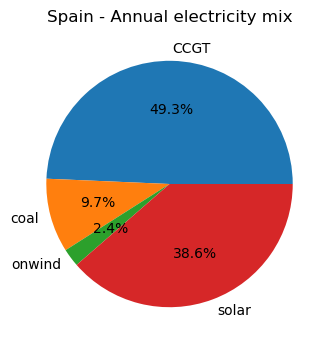

In [89]:
# annual electricity mix in Spain (pie chart)

n.generators_t.p[spain_gens.index].sum().plot.pie(
    figsize=(6, 4), autopct="%1.1f%%", title="Spain - Annual electricity mix"
)
plt.ylabel("")
plt.show()

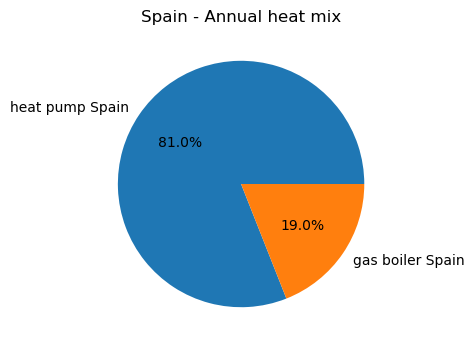

In [90]:
# annual heat mix in Spain (pie chart)

pd.concat(
    [
        -n.links_t.p1[["heat pump Spain"]],
        -n.links_t.p1[["gas boiler Spain"]],
    ],
    axis=1
).sum().plot.pie(figsize=(6, 4), autopct="%1.1f%%", title="Spain - Annual heat mix")
plt.ylabel("")
plt.show()

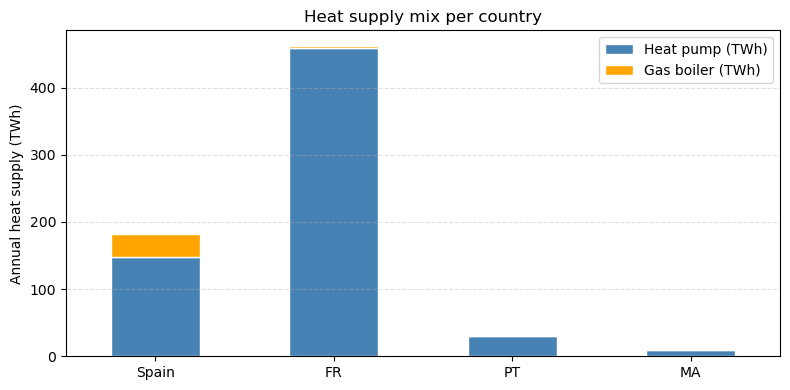

In [91]:
# heat supply mix per country - stacked bar (TWh)

countries = ["Spain", "FR", "PT", "MA"]

heat_supply = pd.DataFrame({
    "Heat pump (TWh)": [
        -n.links_t.p1[f"heat pump {c}"].sum() / 1e6 for c in countries
    ],
    "Gas boiler (TWh)": [
        -n.links_t.p1[f"gas boiler {c}"].sum() / 1e6 for c in countries
    ],
}, index=countries)

fig, ax = plt.subplots(figsize=(8, 4))
heat_supply.plot(kind="bar", stacked=True, ax=ax,
                 color=["steelblue", "orange"], edgecolor="white")
ax.set_ylabel("Annual heat supply (TWh)")
ax.set_title("Heat supply mix per country")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()